In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import glob
import re
import random
import pandas as pd
import pickle as pkl
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
from torchvision import transforms

# Aggiungi la cartella della repository al path per poter importare i moduli DeLAN
# Modifica questo path se necessario per puntare esattamente dove hai clonato la repo
repo_path = '/content/drive/MyDrive/NNDL_PROGETTO/IMPLEMENTAZIONE DELAN E INPUT SIN COS/deep_lagrangian_networks'
sys.path.append(repo_path)

# Importa il modello DeLAN (verifica il nome del file nella repo clonata, solitamente è in 'models')
try:
    from deep_lagrangian_networks.DeLaN_model import DeepLagrangianNetwork
except ImportError:
    # Fallback se la struttura delle cartelle è diversa, prova a cercare direttamente
    print("Tentativo di importazione alternativo...")
    # A seconda di come è strutturata la repo clonata, potresti dover importare diversamente
    # Per ora assumiamo che la classe si chiami DeepLagrangianNetwork

In [31]:
# def load_delan_data(pkl_folder, n_dof):
#     """
#     Carica i dati dai file PKL e li separa in q, dq, ddq, tau
#     per la compatibilità con DeLAN.
#     """
#     columns = [f"{prefix}_{j}" for j in range(1, n_dof+1) for prefix in ("q", "dq", "ddq")]
#     columns += [f"tau_noiseless_{j}" for j in range(1, n_dof+1)]

#     pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))

#     data_list = []

#     for file_path in pkl_files:
#         df = pd.read_pickle(file_path)
#         data_list.append(df[columns].to_numpy())

#     all_data = np.vstack(data_list)

#     # Estrazione delle componenti (assumendo l'ordine q, dq, ddq nelle colonne)
#     # Le colonne sono interlacciate: q1, dq1, ddq1, q2, dq2, ddq2...
#     # Dobbiamo riordinarle per avere [q1, q2...], [dq1, dq2...], etc.

#     q_cols = [col for col in columns if col.startswith('q_')]
#     dq_cols = [col for col in columns if col.startswith('dq_')]
#     ddq_cols = [col for col in columns if col.startswith('ddq_')]
#     tau_cols = [col for col in columns if col.startswith('tau_')]

#     # Usa indici o nomi colonna se il dataframe originale li ha preservati
#     # Qui usiamo lo slicing numpy basato sulla struttura che hai definito nel tuo PklDataset
#     # La tua struttura originale: X contiene 3*n_dof colonne

#     X_raw = all_data[:, :(3*n_dof)]
#     Y_raw = all_data[:, (3*n_dof):] # Tau

#     # Separazione (la tua logica originale era q=x[0::3], dq=x[1::3]...)
#     q = X_raw[:, 0::3]
#     dq = X_raw[:, 1::3]
#     ddq = X_raw[:, 2::3]
#     tau = Y_raw

#     # Conversione in tensori Float
#     return (torch.tensor(q).float(),
#             torch.tensor(dq).float(),
#             torch.tensor(ddq).float(),
#             torch.tensor(tau).float())

# # --- CONFIGURAZIONE ---
# n_dof = 6  # Imposta i gradi di libertà corretti (es. 2, 6, 7)
# train_path = f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/'
# test_path = f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/'

# # Caricamento
# print("Caricamento dati Training...")
# q_train, dq_train, ddq_train, tau_train = load_delan_data(train_path, n_dof)
# print("Caricamento dati Test...")
# q_test, dq_test, ddq_test, tau_test = load_delan_data(test_path, n_dof)

# # Creazione DataLoader
# batch_size = 64
# train_dataset = TensorDataset(q_train, dq_train, ddq_train, tau_train)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# test_dataset = TensorDataset(q_test, dq_test, ddq_test, tau_test)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# print(f"Dati caricati: {len(train_dataset)} samples training.")

In [32]:
class PklDataset(Dataset):
    def __init__(self, pkl_folder, random_choice=False, normalize_y=False, conv_sin_cos=False):
        self.normalize_y = normalize_y
        self.conv_sin_cos = conv_sin_cos

        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Impossibile estrarre i DOF dal nome file: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Definizione colonne basata sulla struttura del file
        columns = [f"{prefix}_{j}" for j in range(1, self.n_dof+1) for prefix in ("q", "dq", "ddq")]
        columns += [f"tau_noiseless_{j}" for j in range(1, self.n_dof+1)]

        pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
        if not pkl_files:
            raise FileNotFoundError(f"Nessun file .pkl trovato in {pkl_folder}")

        data_list = []

        if not random_choice:
            for file_path in pkl_files:
                df = pd.read_pickle(file_path)
                data_list.append(df[columns].to_numpy())
        else:
            file_path = random.choice(pkl_files)
            df = pd.read_pickle(file_path)
            data_list.append(df[columns].to_numpy())

        all_data = np.vstack(data_list)

        # Separazione iniziale: X contiene q, dq, ddq; Y contiene tau
        self.X = all_data[:, :(3 * self.n_dof)]
        self.Y = all_data[:, (3 * self.n_dof):]

        # Calcolo mean/std per tau (Y) per la normalizzazione
        self.mean_y = np.mean(self.Y, axis=0)
        self.std_y = np.std(self.Y, axis=0)
        self.std_y[self.std_y == 0] = 1

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_raw = self.X[idx]
        y_raw = self.Y[idx]

        # Estrazione componenti q, dq, ddq dall'array interlacciato (q1, dq1, ddq1, q2...)
        q   = x_raw[0::3]
        dq  = x_raw[1::3]
        ddq = x_raw[2::3]
        tau = y_raw

        # Eventuale conversione sin/cos per q
        if self.conv_sin_cos:
            q_out = np.empty(2 * self.n_dof, dtype=np.float32)
            q_out[0::2] = np.sin(q)
            q_out[1::2] = np.cos(q)
        else:
            q_out = q.astype(np.float32)

        dq_out = dq.astype(np.float32)
        ddq_out = ddq.astype(np.float32)
        tau_out = tau.astype(np.float32)

        # Normalizzazione tau se richiesta
        if self.normalize_y:
            tau_out = (tau_out - self.mean_y) / self.std_y

        # Conversione in tensori Float
        return (torch.tensor(q_out).float(),
                torch.tensor(dq_out).float(),
                torch.tensor(ddq_out).float(),
                torch.tensor(tau).float())

In [33]:
class ToTensor(object):
    """Convert numpy arrays to torch tensors."""
    def __call__(self, sample):
        import torch
        x, y = sample
        return (torch.from_numpy(x).float(), torch.from_numpy(y).float())

In [34]:
n_dof = 7
composed_transform = transforms.Compose([ToTensor()])

In [35]:
print("Caricamento dati Training...")
train_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/', normalize_y=True)
print("Caricamento dati Validation...")
val_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/val_data/')
print("Caricamento dati Test...")
test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/')

Caricamento dati Training...
Caricamento dati Validation...
Caricamento dati Test...


In [36]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Dati caricati: {len(train_dataset)} samples training.")

Dati caricati: 300060 samples training.


In [37]:
# # --- PARAMETRI MODELLO ---
# # DeLAN richiede di specificare la dimensione dei layer interni
# # H1, H2 sono i neuroni per layer per apprendere le matrici di massa e potenziale
# hidden_units = 128

# # Inizializzazione Modello
# # Nota: Verifica i parametri esatti in base alla versione della repo scaricata.
# # Solitamente richiede (n_dof, num_hidden_units, ...)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = DeepLagrangianNetwork(n_dof, hidden_units=hidden_units).to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# loss_fn = nn.MSELoss()

# # Metrica nMSE (come nel tuo codice originale)
# def compute_nmse(pred, target, std):
#     return torch.mean((pred - target)**2) / (std**2 + 1e-8)

# # Calcolo deviazione standard del target per nMSE
# std_tau_train = torch.std(tau_train, dim=0).to(device)

# print(f"Modello DeLAN inizializzato su {device}")

# # --- TRAINING LOOP ---
# num_epochs = 50
# train_loss_history = []
# val_loss_history = []

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     for b_q, b_dq, b_ddq, b_tau in train_loader:
#         b_q, b_dq, b_ddq, b_tau = b_q.to(device), b_dq.to(device), b_ddq.to(device), b_tau.to(device)

#         optimizer.zero_grad()

#         # Forward pass: DeLAN prende q, dq, ddq e predice tau
#         outputs = model(b_q, b_dq, b_ddq)
#         tau_pred = outputs[0]

#         loss = loss_fn(tau_pred, b_tau)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item() * b_q.size(0)

#     epoch_loss = running_loss / len(train_dataset)
#     train_loss_history.append(epoch_loss)

#     # Validation
#     model.eval()
#     val_loss = 0.0
#     nmse_val = 0.0
#     with torch.no_grad():
#         # Usa tutto il test set in un colpo solo se entra in memoria, altrimenti usa loop
#         q_t = q_test.to(device)
#         dq_t = dq_test.to(device)
#         ddq_t = ddq_test.to(device)
#         tau_t = tau_test.to(device)

#         val_outputs = model(q_t, dq_t, ddq_t)
#         tau_pred_val = val_outputs[0]

#         val_loss = loss_fn(tau_pred_val, tau_t).item()

#         # Calcolo nMSE medio sui giunti
#         nmse_val = torch.mean((tau_pred_val - tau_t)**2, dim=0) / (std_tau_train**2 + 1e-9)
#         nmse_val_mean = torch.mean(nmse_val).item()

#     val_loss_history.append(val_loss)

#     if (epoch+1) % 5 == 0:
#         print(f"Epoch {epoch+1}/{num_epochs} | Train Loss (MSE): {epoch_loss:.6f} | Val Loss (MSE): {val_loss:.6f} | Val nMSE: {nmse_val_mean:.4f}")

# # --- PLOT RISULTATI ---
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.plot(train_loss_history, label='Train MSE')
# plt.plot(val_loss_history, label='Val MSE')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.yscale('log')
# plt.legend()
# plt.title('DeLAN Training Performance')
# plt.show()

In [38]:
# --- PARAMETRI MODELLO ---
# DeLAN richiede di specificare la dimensione dei layer interni
# H1, H2 sono i neuroni per layer per apprendere le matrici di massa e potenziale
hidden_units = [128, 256, 128]

# Inizializzazione Modello
# Nota: Verifica i parametri esatti in base alla versione della repo scaricata.
# Solitamente richiede (n_dof, num_hidden_units, ...)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepLagrangianNetwork(n_dof, hidden_units=hidden_units).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()


In [39]:
# --- 1. Definizione delle Funzioni di Loss ---
loss_fn = nn.MSELoss()

def mse_per_joint(pred, target):
    criterion = nn.MSELoss(reduction='none')
    loss = criterion(pred, target).mean(dim=0)   # shape: (n_joints,)
    return loss

def nmse_per_joint(pred, target, std_dev, eps=1e-8):
    return mse_per_joint(pred, target) / (std_dev**2 + eps)

In [40]:
# num_epochs = 50
# epochs_checkpoint = 0

# # Training log lists
# train_loss_log = []
# train_loss_joints_log = []
# train_loss_nmse_log = []
# train_loss_nmse_per_joint_log = []

# # Validation log lists
# val_loss_log = []
# val_loss_joints_log = []
# val_loss_nmse_log = []
# val_loss_nmse_per_joint_log = []

# # Converting means and stdev to tensor
# train_mean_tensor = torch.tensor(train_dataset.mean_y, dtype=torch.float32, device=device)
# train_std_tensor = torch.tensor(train_dataset.std_y, dtype=torch.float32, device=device)
# val_std_tensor = torch.tensor(val_dataset.std_y, dtype=torch.float32, device=device)

# for epoch_num in range(num_epochs):
#     print('#################')
#     print(f'# EPOCH {epoch_num}')
#     print('#################')

#     if epoch_num % 10 == 0 and epoch_num != 0:
#       checkpoint = {
#           "epoch": epoch_num,
#           "model_state_dict": model.state_dict(),
#           "optimizer_state_dict": optimizer.state_dict(),
#           "train_loss_log": list(train_loss_log),
#           "val_loss_log": list(val_loss_log),
#           "train_loss_nmse_log": list(train_loss_nmse_log),
#           "val_loss_nmse_log": list(val_loss_nmse_log),
#           "train_loss_joints_log": list(train_loss_joints_log),
#           "val_loss_joints_log": list(val_loss_joints_log),
#           "train_loss_nmse_per_joint_log": list(train_loss_nmse_per_joint_log),
#           "val_loss_nmse_per_joint_log": list(val_loss_nmse_per_joint_log)
#       }

#       torch.save(checkpoint, f'/content/drive/MyDrive/NNDL_PROGETTO/models_DELAN/{n_dof}dof/checkpoint_epoch{epoch_num}.pt')
#       print(f"Checkpoint salvato a epoca {epoch_num}")


#     ### TRAIN

#     # Lists containing the losses of the i-th epoch
#     train_loss= []
#     train_loss_nmse= []
#     train_loss_nmse_per_joint = []
#     train_loss_joints = []

#     model.train()
#     for q, dq, ddq, tau in train_dataloader:
#         q, dq, ddq, tau = q.to(device), dq.to(device), ddq.to(device), tau.to(device)

#         # Forward pass
#         out = model(q, dq, ddq)
#         out = out[0]

#         loss = loss_fn(out, tau)

#         with torch.no_grad():
#           #out_denorm = out * train_std_tensor + train_mean_tensor
#           #label_denorm = tau * train_std_tensor + train_mean_tensor
#           loss_nmse_per_joint = nmse_per_joint(out, tau, train_std_tensor)
#           loss_nmse = torch.mean(loss_nmse_per_joint.cpu())
#           loss_per_joint = mse_per_joint(out, tau)
#           loss_mse = loss_fn(out, tau)

#         # Backpropagation
#         model.zero_grad()
#         loss.backward()

#         # Update the weights
#         optimizer.step()

#         # Save train loss for this batch and also for each joints
#         loss_batch = loss_mse.detach().cpu().numpy()
#         train_loss.append(loss_batch)

#         loss_batch_joints = loss_per_joint.cpu().numpy()
#         train_loss_joints.append(loss_batch_joints)

#         loss_batch_nmse = loss_nmse.cpu().numpy()
#         train_loss_nmse.append(loss_batch_nmse)

#         loss_batch_nmse_per_joint = loss_nmse_per_joint.cpu().numpy()
#         train_loss_nmse_per_joint.append(loss_batch_nmse_per_joint)


#     # Save average train loss per epoch
#     train_loss = np.mean(train_loss)
#     print(f"AVERAGE TRAIN LOSS: {train_loss}")
#     train_loss_joints = np.mean(np.vstack(train_loss_joints), axis=0)
#     print(f"TRAIN LOSS PER JOINT: {train_loss_joints}")
#     train_loss_nmse = np.mean(train_loss_nmse)
#     print(f"AVERAGE TRAIN NMSE: {train_loss_nmse}")
#     train_loss_nmse_per_joint = np.mean(np.vstack(train_loss_nmse_per_joint), axis=0)
#     print(f"TRAIN NMSE PER JOINT: {train_loss_nmse_per_joint}")

#     # Update training log vectors
#     train_loss_log.append(train_loss)
#     train_loss_joints_log.append(train_loss_joints)
#     train_loss_nmse_log.append(train_loss_nmse)
#     train_loss_nmse_per_joint_log.append(train_loss_nmse_per_joint)

#     ### VALIDATION
#     val_loss= []
#     val_loss_joints = []
#     val_loss_nmse= []
#     val_loss_nmse_per_joint = []
#     model.eval()
#     with torch.no_grad():
#         for q_val, dq_val, ddq_val, tau_val in val_dataloader:
#             q_val, dq_val, ddq_val, tau_val = q_val.to(device), dq_val.to(device), ddq_val.to(device), tau_val.to(device)

#             # Forward pass
#             out = model(q_val, dq_val, ddq_val)

#             out = out[0]
#             #out = out * train_std_tensor + train_mean_tensor

#             # Compute loss
#             loss = loss_fn(out, tau_val)
#             loss_nmse_per_joint = nmse_per_joint(out, tau_val, val_std_tensor)
#             loss_nmse = torch.mean(loss_nmse_per_joint)
#             loss_per_joint = mse_per_joint(out, tau_val)

#             # Save val loss for this batch
#             loss_batch = loss.cpu().numpy()
#             val_loss.append(loss_batch)

#             loss_batch_joints = loss_per_joint.cpu().numpy()
#             val_loss_joints.append(loss_batch_joints)

#             loss_batch_nmse = loss_nmse.cpu().numpy()
#             val_loss_nmse.append(loss_batch_nmse)

#             loss_batch_nmse_per_joint = loss_nmse_per_joint.cpu().numpy()
#             val_loss_nmse_per_joint.append(loss_batch_nmse_per_joint)


#         # Save average validation loss
#         val_loss = np.mean(val_loss)
#         print(f"AVERAGE VAL LOSS: {val_loss}")
#         val_loss_log.append(val_loss)

#         val_loss_joints = np.mean(np.vstack(val_loss_joints), axis=0)
#         print(f"VAL LOSS JOINTS: {val_loss_joints}")
#         val_loss_joints_log.append(val_loss_joints)

#         val_loss_nmse = np.mean(val_loss_nmse)
#         print(f"AVERAGE VAL NMSE: {val_loss_nmse}")
#         val_loss_nmse_log.append(val_loss_nmse)

#         val_loss_nmse_per_joint = np.mean(np.vstack(val_loss_nmse_per_joint), axis=0)
#         print(f"VAL NMSE PER JOINT: {val_loss_nmse_per_joint}")
#         val_loss_nmse_per_joint_log.append(val_loss_nmse_per_joint)

#         if epoch_num == num_epochs-1:
#           checkpoint = {
#               "epoch": epoch_num,
#               "model_state_dict": model.state_dict(),
#               "optimizer_state_dict": optimizer.state_dict(),
#               "train_loss_log": list(train_loss_log), # copia
#               "val_loss_log": list(val_loss_log),
#               "train_loss_nmse_log": list(train_loss_nmse_log), # copia
#               "val_loss_nmse_log": list(val_loss_nmse_log),
#               "train_loss_joints_log": list(train_loss_joints_log),
#               "val_loss_joints_log": list(val_loss_joints_log),
#               "train_loss_nmse_per_joint_log": list(train_loss_nmse_per_joint_log),
#               "val_loss_nmse_per_joint_log": list(val_loss_nmse_per_joint_log)
#           }

#           torch.save(checkpoint, f'/content/drive/MyDrive/NNDL_PROGETTO/models_DELAN/{n_dof}dof/checkpoint_epoch{epoch_num+1}.pt')
#           print(f"Checkpoint salvato a epoca {epoch_num+1}")

In [41]:
# # --- 2. Inizializzazione Liste di Log ---
# import numpy as np
# import matplotlib.pyplot as plt
# import math

# train_loss_log = []
# val_loss_log = []

# train_loss_nmse_log = []
# val_loss_nmse_log = []

# train_loss_nmse_per_joint_log = []
# val_loss_nmse_per_joint_log = []

# # Nota: Assicurati che n_dof sia definito (es. n_dof = 2)
# # std_tau_train deve essere un tensore di shape (n_dof,) calcolato sui dati di training
# # std_tau_train = torch.std(tau_train, dim=0).to(device)

# print("Inizio Addestramento DeLAN...")

# # --- 3. Training e Validation Loop ---
# for epoch in range(num_epochs):
#     model.train()

#     # Variabili per accumulare le metriche sulle batch
#     epoch_nmse_joints = torch.zeros(n_dof, device=device)
#     epoch_mse_total = 0.0
#     num_batches = 0

#     for b_q, b_dq, b_ddq, b_tau in train_loader:
#         b_q, b_dq, b_ddq, b_tau = b_q.to(device), b_dq.to(device), b_ddq.to(device), b_tau.to(device)

#         optimizer.zero_grad()

#         # Estrazione della coppia (tau) dalla DeLAN
#         outputs = model(b_q, b_dq, b_ddq)
#         tau_pred = outputs[0]

#         # Loss per l'ottimizzazione (MSE standard globale)
#         loss = loss_fn(tau_pred, b_tau)
#         loss.backward()
#         optimizer.step()

#         # Calcolo metriche aggiuntive senza pesare sul gradiente
#         with torch.no_grad():
#             batch_nmse_joints = nmse_per_joint(tau_pred, b_tau, std_tau_train)
#             epoch_nmse_joints += batch_nmse_joints
#             epoch_mse_total += loss.item()
#             num_batches += 1

#     # Media delle metriche sul training set
#     epoch_nmse_joints /= num_batches
#     epoch_mse_total /= num_batches

#     train_loss_log.append(epoch_mse_total)
#     train_loss_nmse_log.append(epoch_nmse_joints.mean().item())
#     train_loss_nmse_per_joint_log.append(epoch_nmse_joints.cpu().numpy())

#     # Validation
#     model.eval()
#     with torch.no_grad():
#         # Assumendo che il test set sia passato tutto in una volta
#         # In caso contrario, usa un ciclo for come nel training
#         q_t = q_test.to(device)
#         dq_t = dq_test.to(device)
#         ddq_t = ddq_test.to(device)
#         tau_t = tau_test.to(device)

#         val_outputs = model(q_t, dq_t, ddq_t)
#         tau_pred_val = val_outputs[0]

#         # Calcolo Loss e metriche sul Validation
#         val_loss = loss_fn(tau_pred_val, tau_t)
#         val_nmse_joints = nmse_per_joint(tau_pred_val, tau_t, std_tau_train)

#         val_loss_log.append(val_loss.item())
#         val_loss_nmse_log.append(val_nmse_joints.mean().item())
#         val_loss_nmse_per_joint_log.append(val_nmse_joints.cpu().numpy())

#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{num_epochs} | Train nMSE: {train_loss_nmse_log[-1]:.4f} | Val nMSE: {val_loss_nmse_log[-1]:.4f}")

# print("Addestramento Completato!")


# # --- 4. Preparazione Dati per Plot ---
# # Converti in numpy array
# train_loss_nmse_log = np.array(train_loss_nmse_log)                     # (epochs,)
# val_loss_nmse_log = np.array(val_loss_nmse_log)                         # (epochs,)
# train_loss_nmse_per_joint_log = np.array(train_loss_nmse_per_joint_log)       # (epochs, n_joints)
# val_loss_nmse_per_joint_log = np.array(val_loss_nmse_per_joint_log)           # (epochs, n_joints)

# num_epochs_plot = len(train_loss_log)
# n_joints = train_loss_nmse_per_joint_log.shape[1]

# # --- 5. Plot Totale ---
# plt.figure(figsize=(8, 5))
# plt.plot(range(num_epochs_plot), train_loss_nmse_log, label="Train total")
# plt.plot(range(num_epochs_plot), val_loss_nmse_log, label="Val total")
# plt.xlabel("Epoch")
# plt.ylabel("NMSE (average)")
# plt.title("Training and Validation Loss (total NMSE)")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # --- 6. Plot per Giunto ---
# # Distribuisci i plot in una griglia quadrata il più possibile bilanciata
# n_cols = math.ceil(math.sqrt(n_joints))
# n_rows = math.ceil(n_joints / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True)

# # Se axes è un singolo oggetto (es. 1 solo joint), lo forziamo ad array
# if not isinstance(axes, np.ndarray):
#     axes = np.array([axes])
# # Se axes è 2D, lo rendo 1D per comodità
# axes = axes.reshape(-1)

# for j in range(n_joints):
#     axes[j].plot(range(num_epochs_plot), train_loss_nmse_per_joint_log[:, j], label=f"Train Joint {j+1}")
#     axes[j].plot(range(num_epochs_plot), val_loss_nmse_per_joint_log[:, j], label=f"Val Joint {j+1}")
#     axes[j].set_title(f"Joint {j+1}")
#     axes[j].set_ylabel("NMSE")
#     axes[j].grid(True)
#     axes[j].legend(fontsize=8)

# # Nascondi subplot vuoti (se il numero di giunti non riempie tutta la griglia)
# for ax in axes[n_joints:]:
#     ax.set_visible(False)

# # Etichetta solo l’asse x dell’ultima riga visibile
# for ax in axes[-n_cols:]:
#     if ax.get_visible():
#         ax.set_xlabel("Epoch")

# plt.suptitle("Per-joint Training and Validation NMSE", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

In [44]:
checkpoint = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_DELAN/{n_dof}dof/checkpoint_epoch50.pt', map_location=device if device.type == "cpu" else None,
    weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch = checkpoint["epoch"]  # riparti dalla successiva
train_loss_log = checkpoint["train_loss_log"]
val_loss_log = checkpoint["val_loss_log"]
train_loss_nmse_log = checkpoint["train_loss_nmse_log"]
val_loss_nmse_log = checkpoint["val_loss_nmse_log"]
train_loss_joints_log = checkpoint["train_loss_joints_log"]
val_loss_joints_log = checkpoint["val_loss_joints_log"]
train_loss_nmse_per_joint_log = checkpoint["train_loss_nmse_per_joint_log"]
val_loss_nmse_per_joint_log = checkpoint["val_loss_nmse_per_joint_log"]



print(f"Riprendo da epoca {start_epoch}")

Riprendo da epoca 49


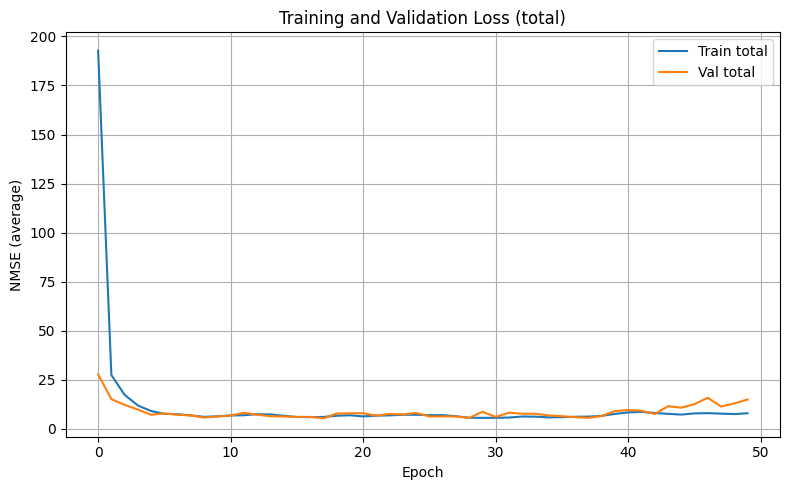

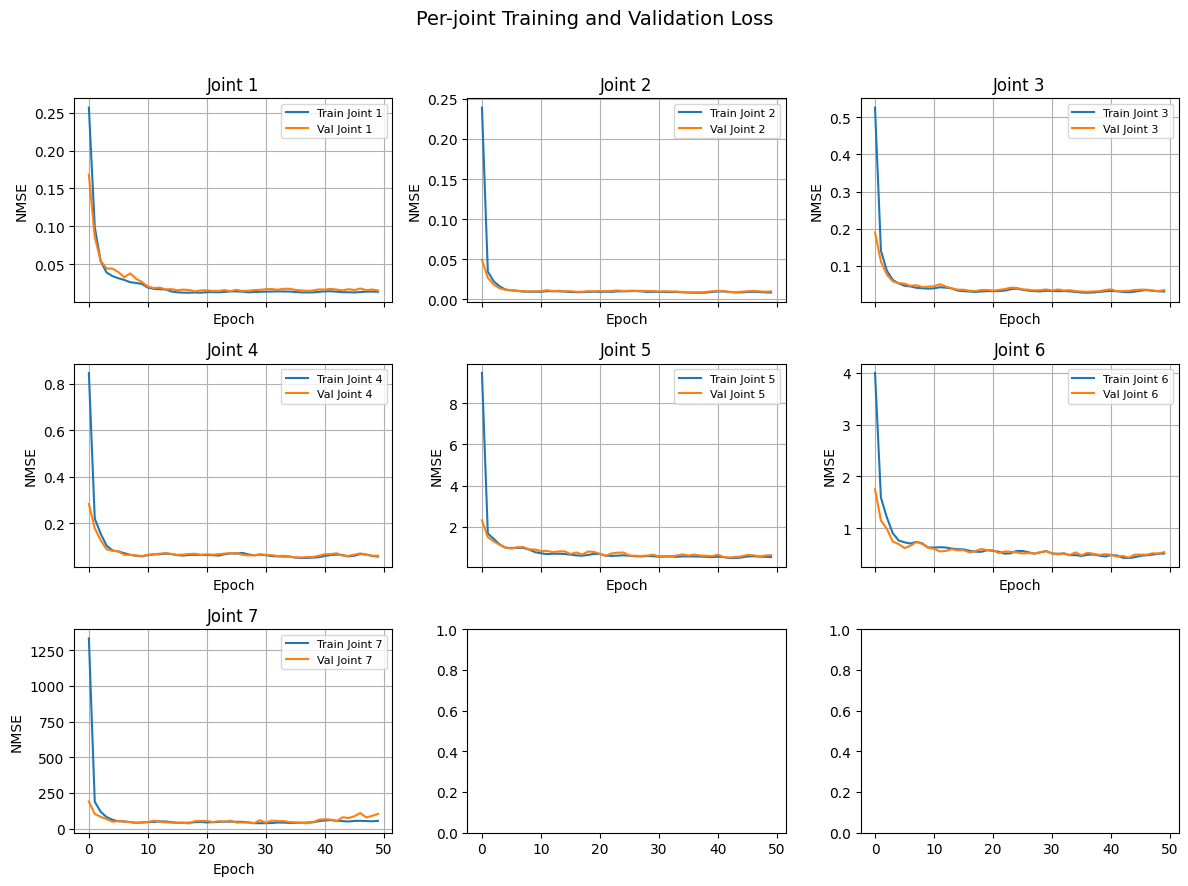

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Convertion to numpy array
train_loss_nmse_log = np.array(train_loss_nmse_log)                     # (epochs,)
val_loss_nmse_log = np.array(val_loss_nmse_log)                         # (epochs,)
train_loss_nmse_per_joint_log = np.array(train_loss_nmse_per_joint_log)       # (epochs, n_joints)
val_loss_nmse_per_joint_log = np.array(val_loss_nmse_per_joint_log)           # (epochs, n_joints)

num_epochs = len(train_loss_log)
n_joints = train_loss_nmse_per_joint_log.shape[1]

# General plot
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_loss_nmse_log, label="Train total")
plt.plot(range(num_epochs), val_loss_nmse_log, label="Val total")
plt.xlabel("Epoch")
plt.ylabel("NMSE (average)")
plt.title("Training and Validation Loss (total)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Per-joint plot
n_cols = math.ceil(math.sqrt(n_joints))
n_rows = math.ceil(n_joints / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True)

axes = np.array(axes).reshape(-1)

for j in range(n_joints):
    axes[j].plot(range(num_epochs), train_loss_nmse_per_joint_log[:, j], label=f"Train Joint {j+1}")
    axes[j].plot(range(num_epochs), val_loss_nmse_per_joint_log[:, j], label=f"Val Joint {j+1}")
    axes[j].set_title(f"Joint {j+1}")
    axes[j].set_ylabel("NMSE")
    axes[j].set_xlabel("Epoch")
    axes[j].grid(True)
    axes[j].legend(fontsize=8)



plt.suptitle("Per-joint Training and Validation Loss", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Traiettoria selezionata per il plot: panda_7dof_data_inv_dyn_sum_of_sin__noise_std0.01__w_f0.02__num_sin50__pos_range_0.8__50seconds__Ts_0.01__seed107.pkl


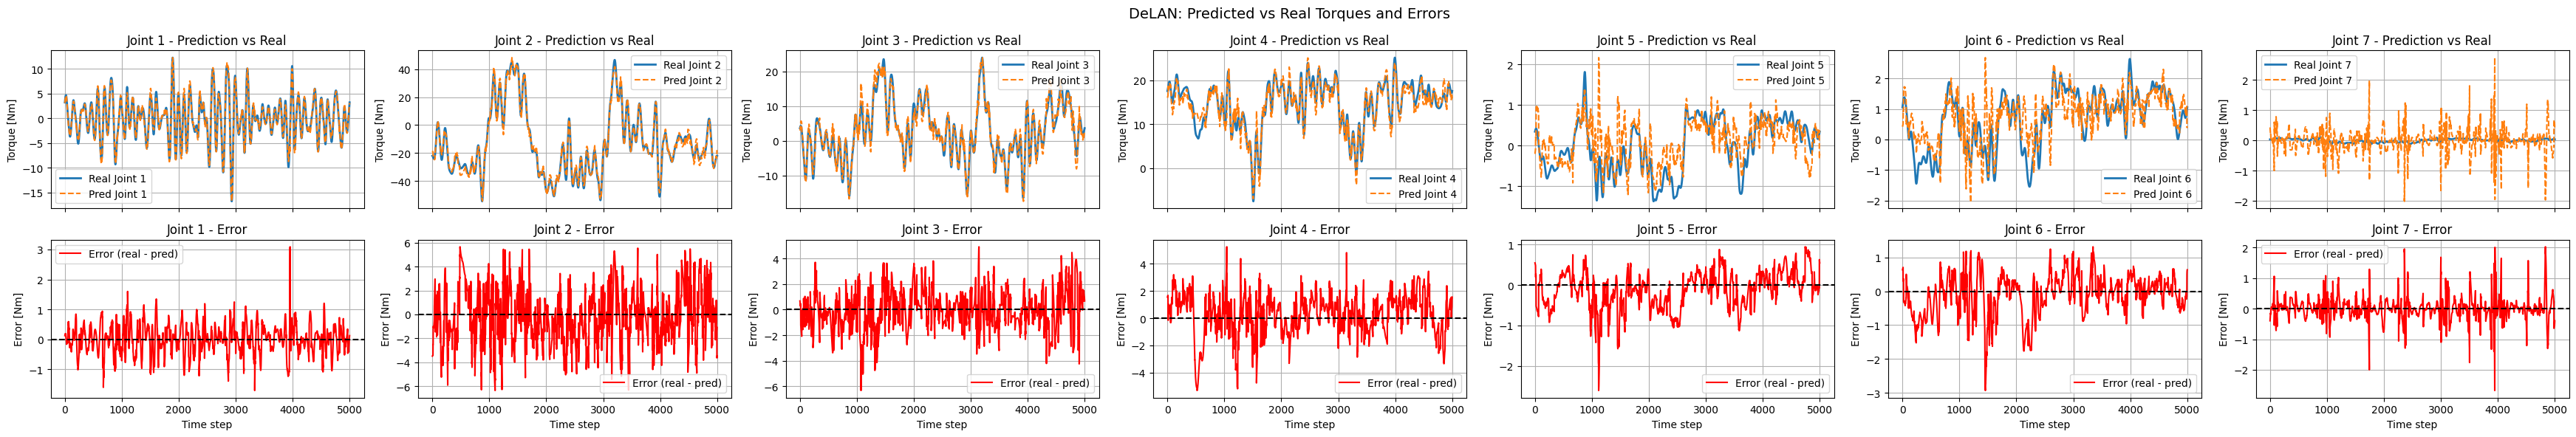

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

# --- 1. Caricamento di UNA traiettoria random per il test ---
def load_single_trajectory_delan(pkl_folder, n_dof):
    """Sceglie un file .pkl a caso per plottare una traiettoria continua."""
    pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
    random_file = random.choice(pkl_files)
    print(f"Traiettoria selezionata per il plot: {os.path.basename(random_file)}")

    df = pd.read_pickle(random_file)

    # Nomi delle colonne (q, dq, ddq e tau)
    columns = [f"{prefix}_{j}" for j in range(1, n_dof+1) for prefix in ("q", "dq", "ddq")]
    columns += [f"tau_noiseless_{j}" for j in range(1, n_dof+1)]
    data = df[columns].to_numpy()

    # Separazione
    X_raw = data[:, :(3*n_dof)]
    Y_raw = data[:, (3*n_dof):]

    q = torch.tensor(X_raw[:, 0::3]).float()
    dq = torch.tensor(X_raw[:, 1::3]).float()
    ddq = torch.tensor(X_raw[:, 2::3]).float()
    tau = torch.tensor(Y_raw).float()

    return q, dq, ddq, tau

# Assicurati che n_dof e test_path siano definiti
test_path = f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/'

q_traj, dq_traj, ddq_traj, tau_traj = load_single_trajectory_delan(test_path, n_dof)
test_trajectory_dataset = TensorDataset(q_traj, dq_traj, ddq_traj, tau_traj)
test_trajectory_dataloader = DataLoader(test_trajectory_dataset, batch_size=64, shuffle=False)

# --- 2. Inferenza con DeLAN ---
all_outputs_traj = []
all_labels_traj = []

model.eval() # Imposta la DeLAN in evaluation mode
with torch.no_grad():
    for b_q, b_dq, b_ddq, b_tau in test_trajectory_dataloader:
        # Move data to device
        b_q, b_dq, b_ddq = b_q.to(device), b_dq.to(device), b_ddq.to(device)
        b_tau = b_tau.to(device)

        # Forward pass: ricordati che la DeLAN richiede i 3 input separati
        outputs = model(b_q, b_dq, b_ddq)
        out_traj = outputs[0] # Estrai la torque predetta

        # Salvataggio
        all_outputs_traj.append(out_traj)
        all_labels_traj.append(b_tau)

# Concatenate all the outputs and labels
all_outputs_traj = torch.cat(all_outputs_traj)
all_labels_traj = torch.cat(all_labels_traj)

# Convert to CPU e numpy
outputs_np = all_outputs_traj.cpu().numpy()
labels_np = all_labels_traj.cpu().numpy()

# --- 3. Plot ---
n_samples, n_joints = outputs_np.shape
time = range(n_samples)  # asse x: step temporali

# Se hai un solo giunto, subplots restituisce un array 1D, forziamo il 2D
fig, axes = plt.subplots(2, n_joints, figsize=(5 * n_joints, 6), sharex=True, squeeze=False)

# --- Predetto vs Reale ---
for j in range(n_joints):
    axes[0, j].plot(time, labels_np[:, j], label=f"Real Joint {j+1}", linewidth=2)
    axes[0, j].plot(time, outputs_np[:, j], label=f"Pred Joint {j+1}", linestyle="--")
    axes[0, j].set_ylabel("Torque [Nm]")
    axes[0, j].legend()
    axes[0, j].grid(True)
    axes[0, j].set_title(f"Joint {j+1} - Prediction vs Real")

# --- Errore ---
errors = labels_np - outputs_np
for j in range(n_joints):
    axes[1, j].plot(time, errors[:, j], color="red", label="Error (real - pred)")
    axes[1, j].axhline(0, color="black", linestyle="--")
    axes[1, j].set_ylabel("Error [Nm]")
    axes[1, j].legend()
    axes[1, j].grid(True)
    axes[1, j].set_title(f"Joint {j+1} - Error")
    axes[1, j].set_xlabel("Time step")

plt.suptitle("DeLAN: Predicted vs Real Torques and Errors", fontsize=14)
plt.tight_layout()
plt.show()